In [139]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 🔧 STEP 1: MASTER CONFIGURATION
# ==========================================

# 1. File & Device Settings
FILENAME      = r'C:\Users\DELL\Documents\GitHub\fyp\05_Data_Storage\Windowed\raafiq_U08\raafiq_U08_Win0.csv'
FS            = 400.0                
USE_FULL_FILE = True                 # ⚡ Set True to process the whole CSV

# 2. ✂️ DATA SELECTION
SAMPLE_START  = 0                   
SAMPLE_END    = 2000                

# 3. Plotting Settings (NEW!)
SUBPLOT_HEIGHT              = 4.0   # Height of EACH individual graph (Inches)
TIME_VERTICAL_LINE_INTERVAL = 1.0   # ⚡ Draw vertical line every X seconds
FREQ_VERTICAL_LINE_INTERVAL = 1.0   # ⚡ Draw vertical line every X Hz

# 4. Validity Thresholds
THRESHOLD_RED = 1000
THRESHOLD_IR  = 1000

# --- Spike Removal Settings ---
SPIKE_ENABLE  = False               
KERNEL_SIZE   = 51                   

# --- Signal Inversion ---
INVERT_ENABLE = True                

# --- Low Pass Filter ---
LP_ENABLE     = True                
LP_CUTOFF     = 16.0                
LP_ORDER      = 4

# --- High Pass Filter ---
HP_ENABLE     = True                
HP_CUTOFF     = 0.5                 
HP_ORDER      = 4

# --- Savitzky-Golay Smoothing ---
SG_ENABLE     = True                
SG_WINDOW     = 31                  
SG_POLY       = 3                   

# --- Normalization ---
NORM_SELECTION = 1                  # 1=MinMax, 2=ZScore

# ==========================================
# 📊 SQI LIMITS
# ==========================================
SQI_LIMITS = {
    'SKEWNESS_MIN': -1.0,  'SKEWNESS_MAX': 3.0,
    'KURTOSIS_MIN': -1.0,  'KURTOSIS_MAX': 5.0,
    'PI_MIN':        0.1,  
    'SNR_MIN_DB':    5.0,
    'ZCR_MAX':       4.0 
}

# ==========================================
# 🛠️ HELPER FUNCTIONS
# ==========================================
def apply_normalization(data, selection=1):
    if len(data) == 0: return data
    if selection == 1: return (data - np.min(data)) / (np.max(data) - np.min(data))
    elif selection == 2: return (data - np.mean(data)) / np.std(data)
    return data

# ==========================================
# 📐 AUTOMATIC CALCULATIONS
# ==========================================
if USE_FULL_FILE:
    try:
        with open(FILENAME) as f:
            row_count = sum(1 for line in f) - 1
        SAMPLE_START = 0
        SAMPLE_END   = row_count
        print(f"📂 Full File Mode ON. Samples: {row_count}")
    except Exception as e:
        print(f"⚠️ Error reading file length: {e}")

total_samples = SAMPLE_END - SAMPLE_START
plot_time     = total_samples / FS
nyquist_rate  = FS / 2.0

print("✅ Configuration Loaded.")
print(f"⏱️  Duration: {plot_time:.2f}s | Plot Height: {SUBPLOT_HEIGHT} inches")
print(f"📏 Grid: Time={TIME_VERTICAL_LINE_INTERVAL}s | Freq={FREQ_VERTICAL_LINE_INTERVAL}Hz")

📂 Full File Mode ON. Samples: 4000
✅ Configuration Loaded.
⏱️  Duration: 10.00s | Plot Height: 4.0 inches
📏 Grid: Time=1.0s | Freq=1.0Hz


✅ Processing Range: 4000 samples (10.00 seconds).


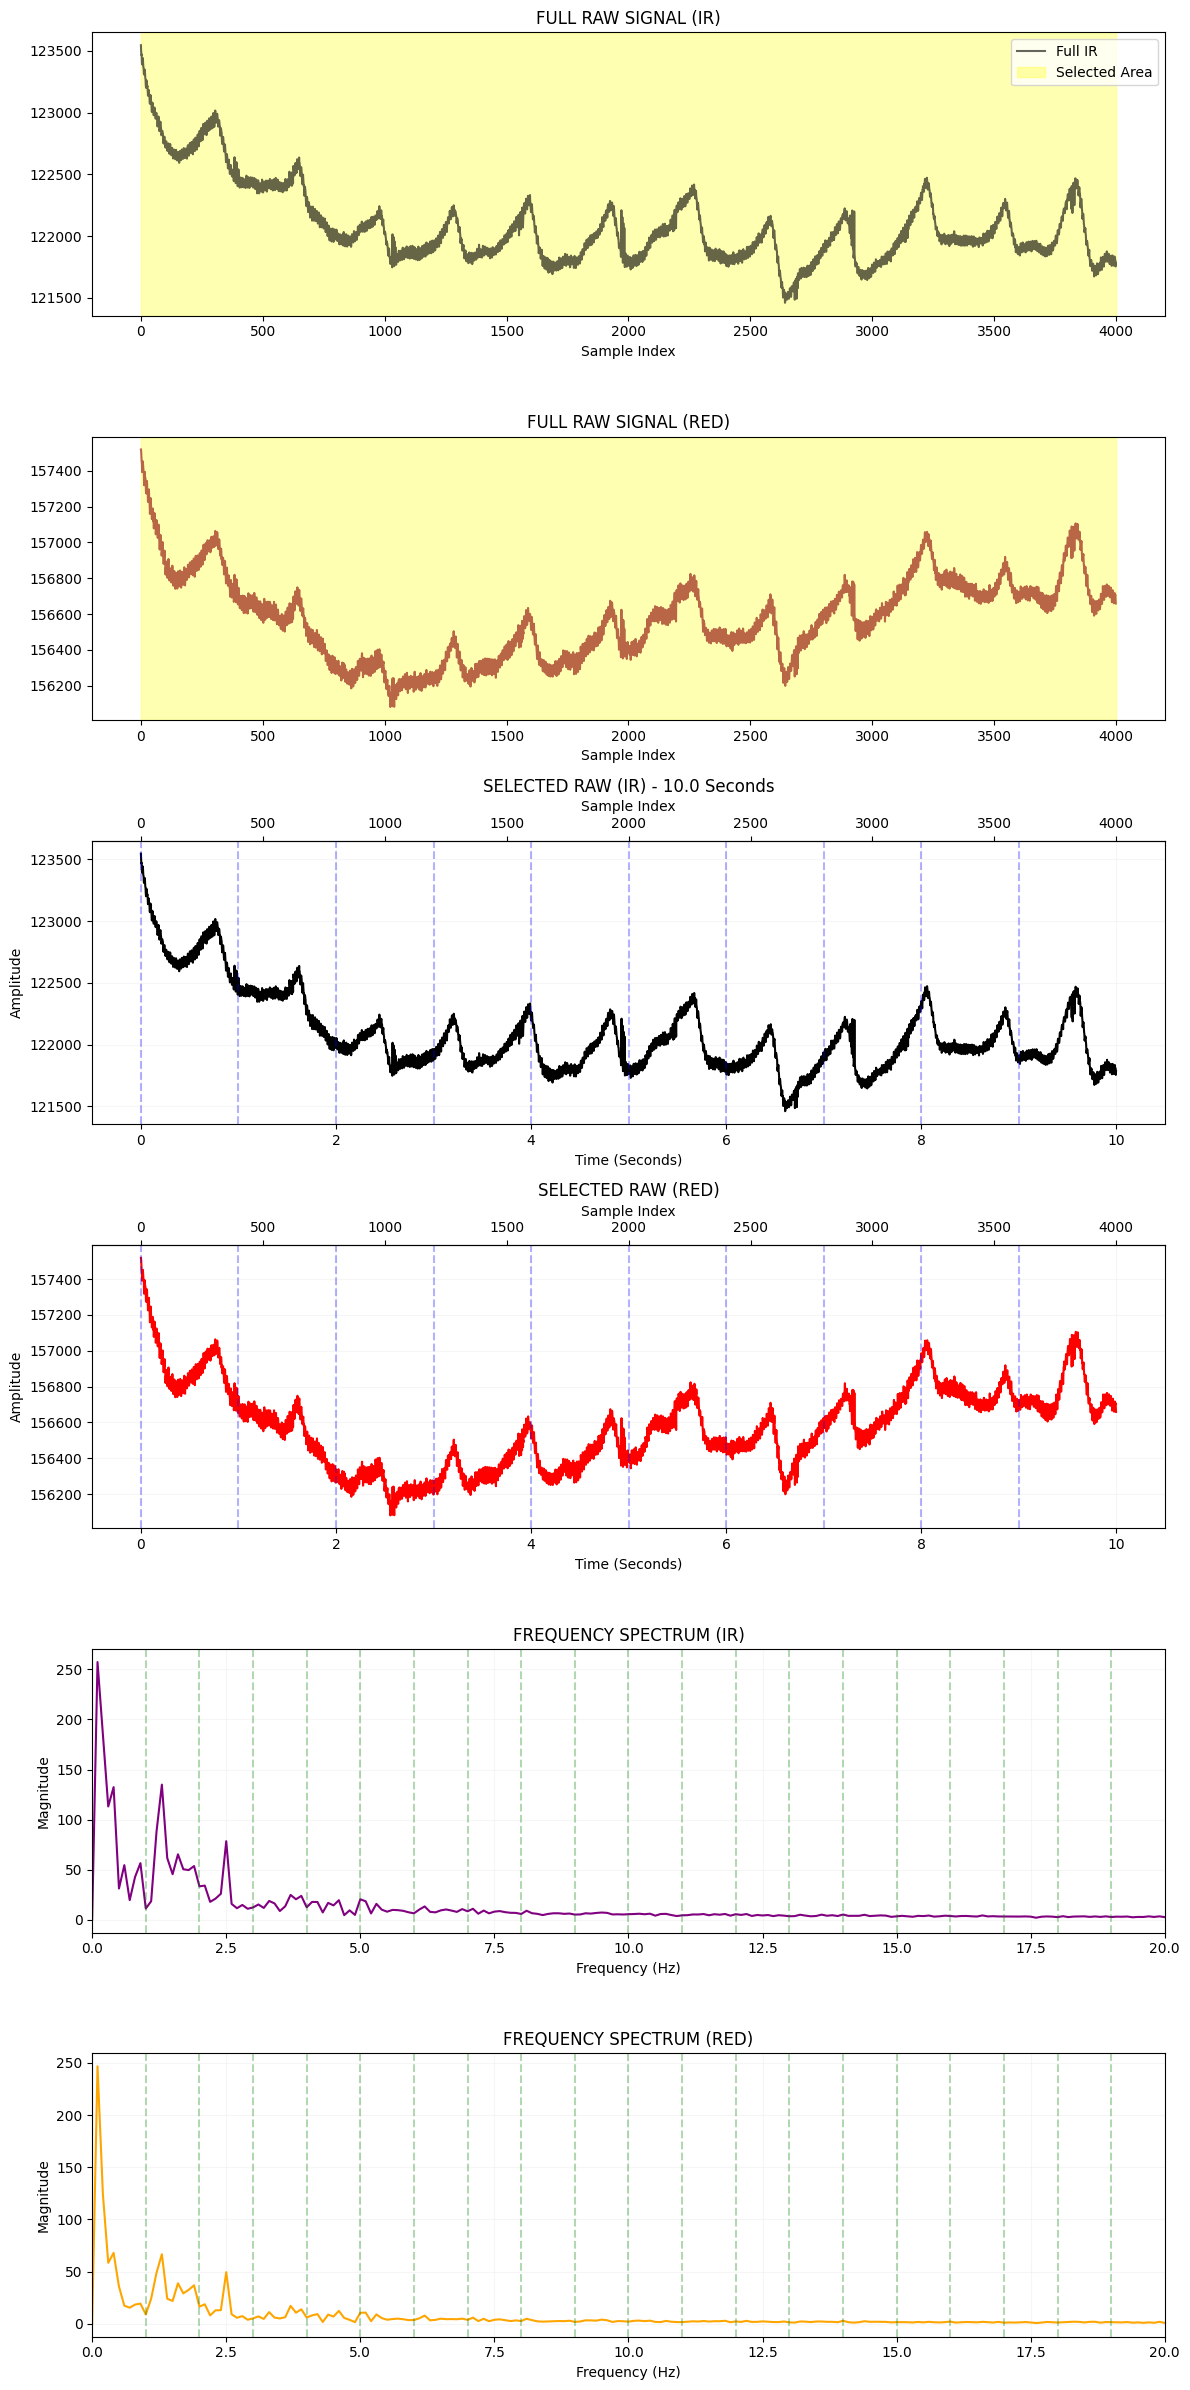

In [140]:
# ==========================================
# ⚙️ STEP 2: LOAD, SELECT, TIME & FREQ PLOTS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 1. Load CSV
df = pd.read_csv(FILENAME)
df.columns = df.columns.str.strip().str.upper()

rename_map = {
    'RED_VALUE': 'RED', 'IR_VALUE': 'IR', 
    'RED VALUE': 'RED', 'IR VALUE': 'IR',
    'RED_RAW': 'RED',   'IR_RAW': 'IR'
}
df = df.rename(columns=rename_map)

# 2. Apply Validity Thresholds
mask = (df['RED'] > THRESHOLD_RED) & (df['IR'] > THRESHOLD_IR)
full_clean_df = df[mask].copy()
full_clean_df = full_clean_df.reset_index(drop=True)

# 3. ✂️ APPLY SELECTION
if USE_FULL_FILE:
    selected_df = full_clean_df.copy()
    SAMPLE_START = 0
    SAMPLE_END = len(selected_df)
else:
    s_end = min(SAMPLE_END, len(full_clean_df))
    selected_df = full_clean_df.iloc[SAMPLE_START:s_end].copy()

# --- FFT HELPER ---
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data)
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# --- SAFETY CHECK & PLOTTING ---
if len(selected_df) < 50:
    print(f"❌ CRITICAL ERROR: Selected range is too short ({len(selected_df)} samples)!")
else:
    print(f"✅ Processing Range: {len(selected_df)} samples ({len(selected_df)/FS:.2f} seconds).")

    # Generate Time Axis (Seconds)
    time_axis = np.arange(len(selected_df)) / FS
    
    # DYNAMIC FIGURE SIZE
    total_fig_height = SUBPLOT_HEIGHT * 6
    fig, axes = plt.subplots(6, 1, figsize=(12, total_fig_height))
    plt.subplots_adjust(hspace=0.6) # Increase spacing for dual axes

    # --- PLOT 1: FULL Data (IR) ---
    axes[0].plot(full_clean_df['IR'].values, color='black', alpha=0.6, label='Full IR')
    axes[0].axvspan(SAMPLE_START, SAMPLE_END, color='yellow', alpha=0.3, label='Selected Area')
    axes[0].set_title('FULL RAW SIGNAL (IR)')
    axes[0].set_xlabel('Sample Index')
    axes[0].legend(loc='upper right')

    # --- PLOT 2: FULL Data (RED) ---
    axes[1].plot(full_clean_df['RED'].values, color='darkred', alpha=0.6, label='Full RED')
    axes[1].axvspan(SAMPLE_START, SAMPLE_END, color='yellow', alpha=0.3)
    axes[1].set_title('FULL RAW SIGNAL (RED)')
    axes[1].set_xlabel('Sample Index')

    # --- PLOT 3: SELECTED IR (Time Axis) ---
    axes[2].plot(time_axis, selected_df['IR'].values, color='black', linewidth=1.5)
    axes[2].set_title(f'SELECTED RAW (IR) - {len(selected_df)/FS:.1f} Seconds')
    axes[2].set_ylabel('Amplitude')
    axes[2].set_xlabel('Time (Seconds)') 
    
    sec_ax1 = axes[2].secondary_xaxis('top', functions=(lambda x: x*FS, lambda x: x/FS))
    sec_ax1.set_xlabel('Sample Index')

    # --- PLOT 4: SELECTED RED (Time Axis) ---
    axes[3].plot(time_axis, selected_df['RED'].values, color='red', linewidth=1.5)
    axes[3].set_title(f'SELECTED RAW (RED)')
    axes[3].set_ylabel('Amplitude')
    axes[3].set_xlabel('Time (Seconds)') 

    sec_ax2 = axes[3].secondary_xaxis('top', functions=(lambda x: x*FS, lambda x: x/FS))
    sec_ax2.set_xlabel('Sample Index')

    # --- TIME VERTICAL LINES ---
    if TIME_VERTICAL_LINE_INTERVAL > 0:
        grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
        for ax in [axes[2], axes[3]]:
            for sec in grid_seconds:
                ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
            ax.grid(True, which='both', linestyle='-', alpha=0.1)

    # --- PLOT 5: FFT IR ---
    xf_ir, yf_ir = compute_fft(selected_df['IR'].values - np.mean(selected_df['IR'].values), FS)
    axes[4].plot(xf_ir, yf_ir, color='purple')
    axes[4].set_title('FREQUENCY SPECTRUM (IR)')
    axes[4].set_ylabel('Magnitude')
    axes[4].set_xlabel('Frequency (Hz)')
    axes[4].set_xlim(0, 20) 
    
    # --- PLOT 6: FFT RED ---
    xf_red, yf_red = compute_fft(selected_df['RED'].values - np.mean(selected_df['RED'].values), FS)
    axes[5].plot(xf_red, yf_red, color='orange')
    axes[5].set_title('FREQUENCY SPECTRUM (RED)')
    axes[5].set_ylabel('Magnitude')
    axes[5].set_xlabel('Frequency (Hz)')
    axes[5].set_xlim(0, 20) 

    # --- FREQUENCY VERTICAL LINES ---
    if FREQ_VERTICAL_LINE_INTERVAL > 0:
        # Generate grid: 0, 1.0, 2.0 ... up to 20Hz (since we set limit to 20)
        grid_freqs = np.arange(0, 20, FREQ_VERTICAL_LINE_INTERVAL)
        for ax in [axes[4], axes[5]]:
            for freq in grid_freqs:
                ax.axvline(x=freq, color='green', linestyle='--', alpha=0.3)
            ax.grid(True, which='both', linestyle='-', alpha=0.1)

    plt.tight_layout()
    plt.show()

⚠️ SPIKE REMOVAL: DISABLED (Skipping...)


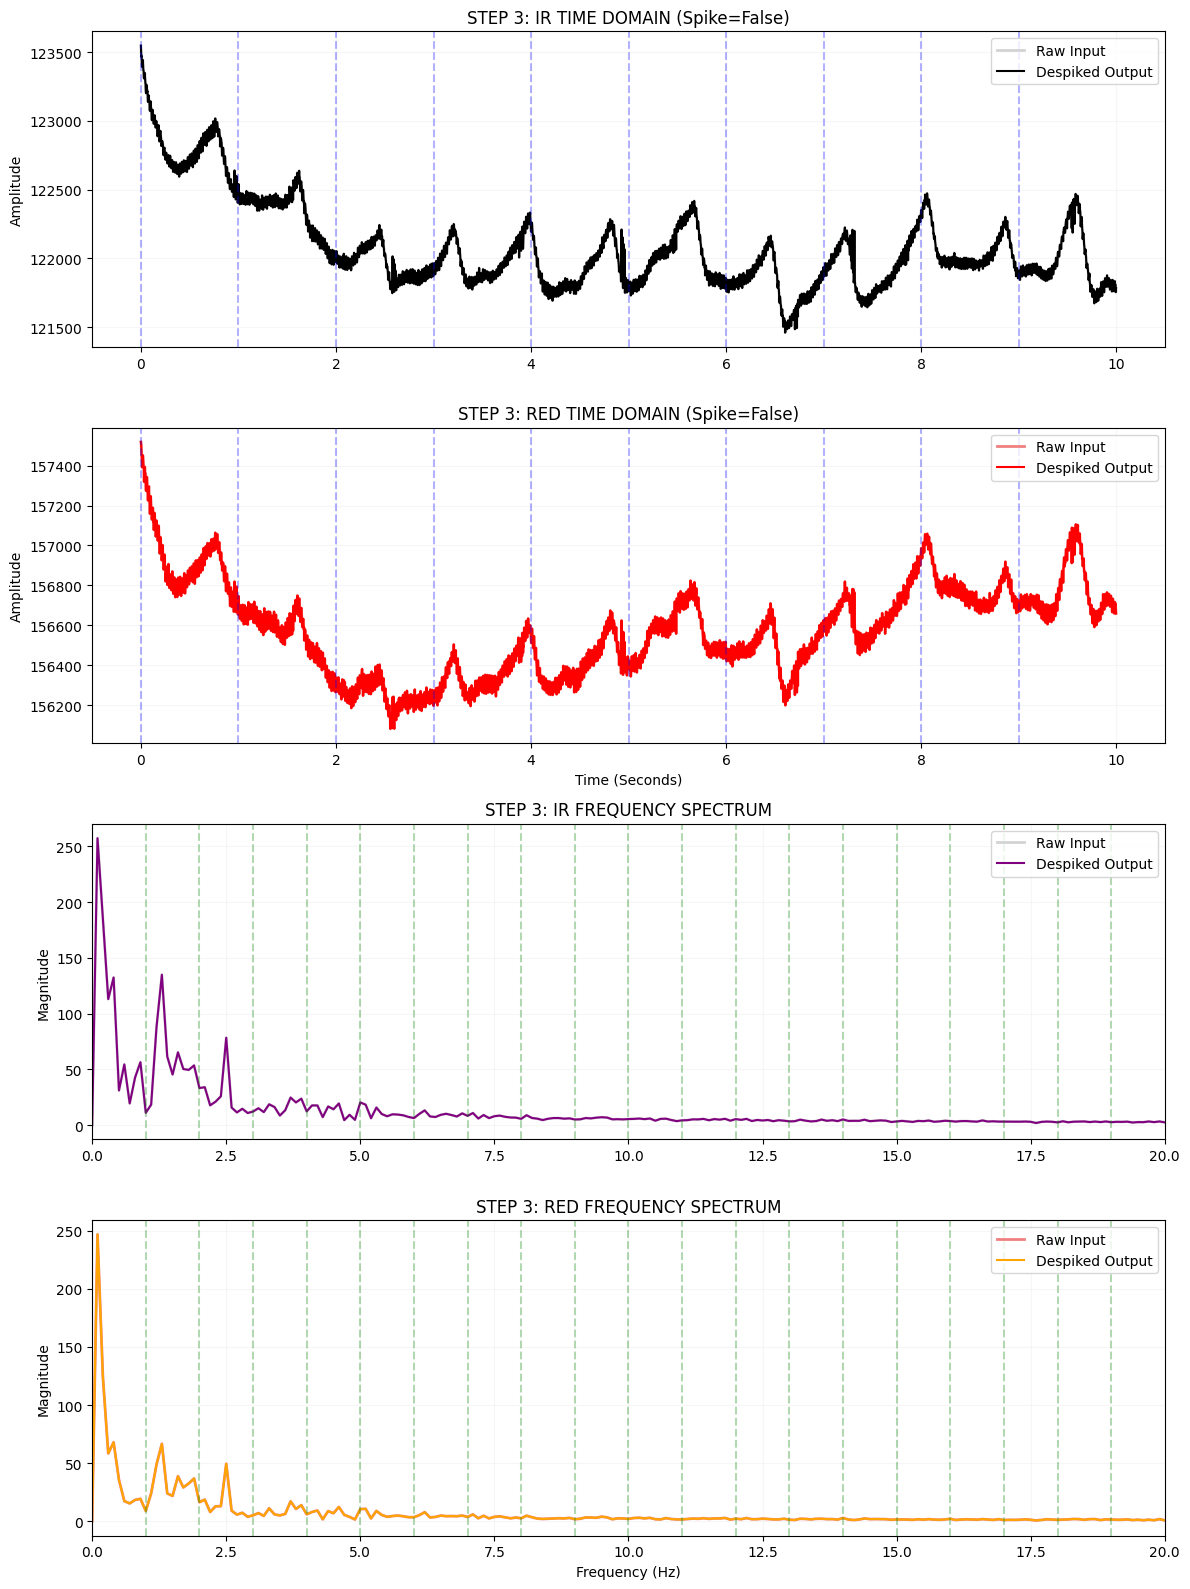

In [141]:
# ==========================================
# ⚙️ STEP 3: SPIKE REMOVAL (TIME + FREQ)
# ==========================================
import scipy.signal as signal
from scipy.fft import fft, fftfreq

# 1. Check Toggle Switch & Process
if SPIKE_ENABLE:
    print(f"⚡ SPIKE REMOVAL: ENABLED (Kernel Size: {KERNEL_SIZE})")
    ir_despiked  = signal.medfilt(selected_df['IR'].values, kernel_size=KERNEL_SIZE)
    red_despiked = signal.medfilt(selected_df['RED'].values, kernel_size=KERNEL_SIZE)
else:
    print("⚠️ SPIKE REMOVAL: DISABLED (Skipping...)")
    ir_despiked  = selected_df['IR'].values.copy()
    red_despiked = selected_df['RED'].values.copy()

# 2. FFT Helper Function
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data)) # Remove DC offset
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# 3. Setup Plotting
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4  # 4 Plots now
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR (Time) ---
axes[0].plot(time_axis, selected_df['IR'].values, color='lightgray', label='Raw Input', linewidth=2)
axes[0].plot(time_axis, ir_despiked, color='black', linewidth=1.5, label='Despiked Output')
axes[0].set_title(f'STEP 3: IR TIME DOMAIN (Spike={SPIKE_ENABLE})')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED (Time) ---
axes[1].plot(time_axis, selected_df['RED'].values, color='lightcoral', label='Raw Input', linewidth=2)
axes[1].plot(time_axis, red_despiked, color='red', linewidth=1.5, label='Despiked Output')
axes[1].set_title(f'STEP 3: RED TIME DOMAIN (Spike={SPIKE_ENABLE})')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- VERTICAL LINES (Time) ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        for sec in grid_seconds:
            ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

# --- PLOT 3: IR (Frequency) ---
xf_raw, yf_raw = compute_fft(selected_df['IR'].values, FS)
xf_out, yf_out = compute_fft(ir_despiked, FS)

axes[2].plot(xf_raw, yf_raw, color='lightgray', label='Raw Input', linewidth=2)
axes[2].plot(xf_out, yf_out, color='purple', label='Despiked Output', linewidth=1.5)
axes[2].set_title('STEP 3: IR FREQUENCY SPECTRUM')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 20)
axes[2].legend(loc='upper right')

# --- PLOT 4: RED (Frequency) ---
xf_raw_r, yf_raw_r = compute_fft(selected_df['RED'].values, FS)
xf_out_r, yf_out_r = compute_fft(red_despiked, FS)

axes[3].plot(xf_raw_r, yf_raw_r, color='lightcoral', label='Raw Input', linewidth=2)
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Despiked Output', linewidth=1.5)
axes[3].set_title('STEP 3: RED FREQUENCY SPECTRUM')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 20)
axes[3].legend(loc='upper right')

# --- VERTICAL LINES (Frequency) ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    grid_freqs = np.arange(0, 20, FREQ_VERTICAL_LINE_INTERVAL)
    for ax in [axes[2], axes[3]]:
        for freq in grid_freqs:
            ax.axvline(x=freq, color='green', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.


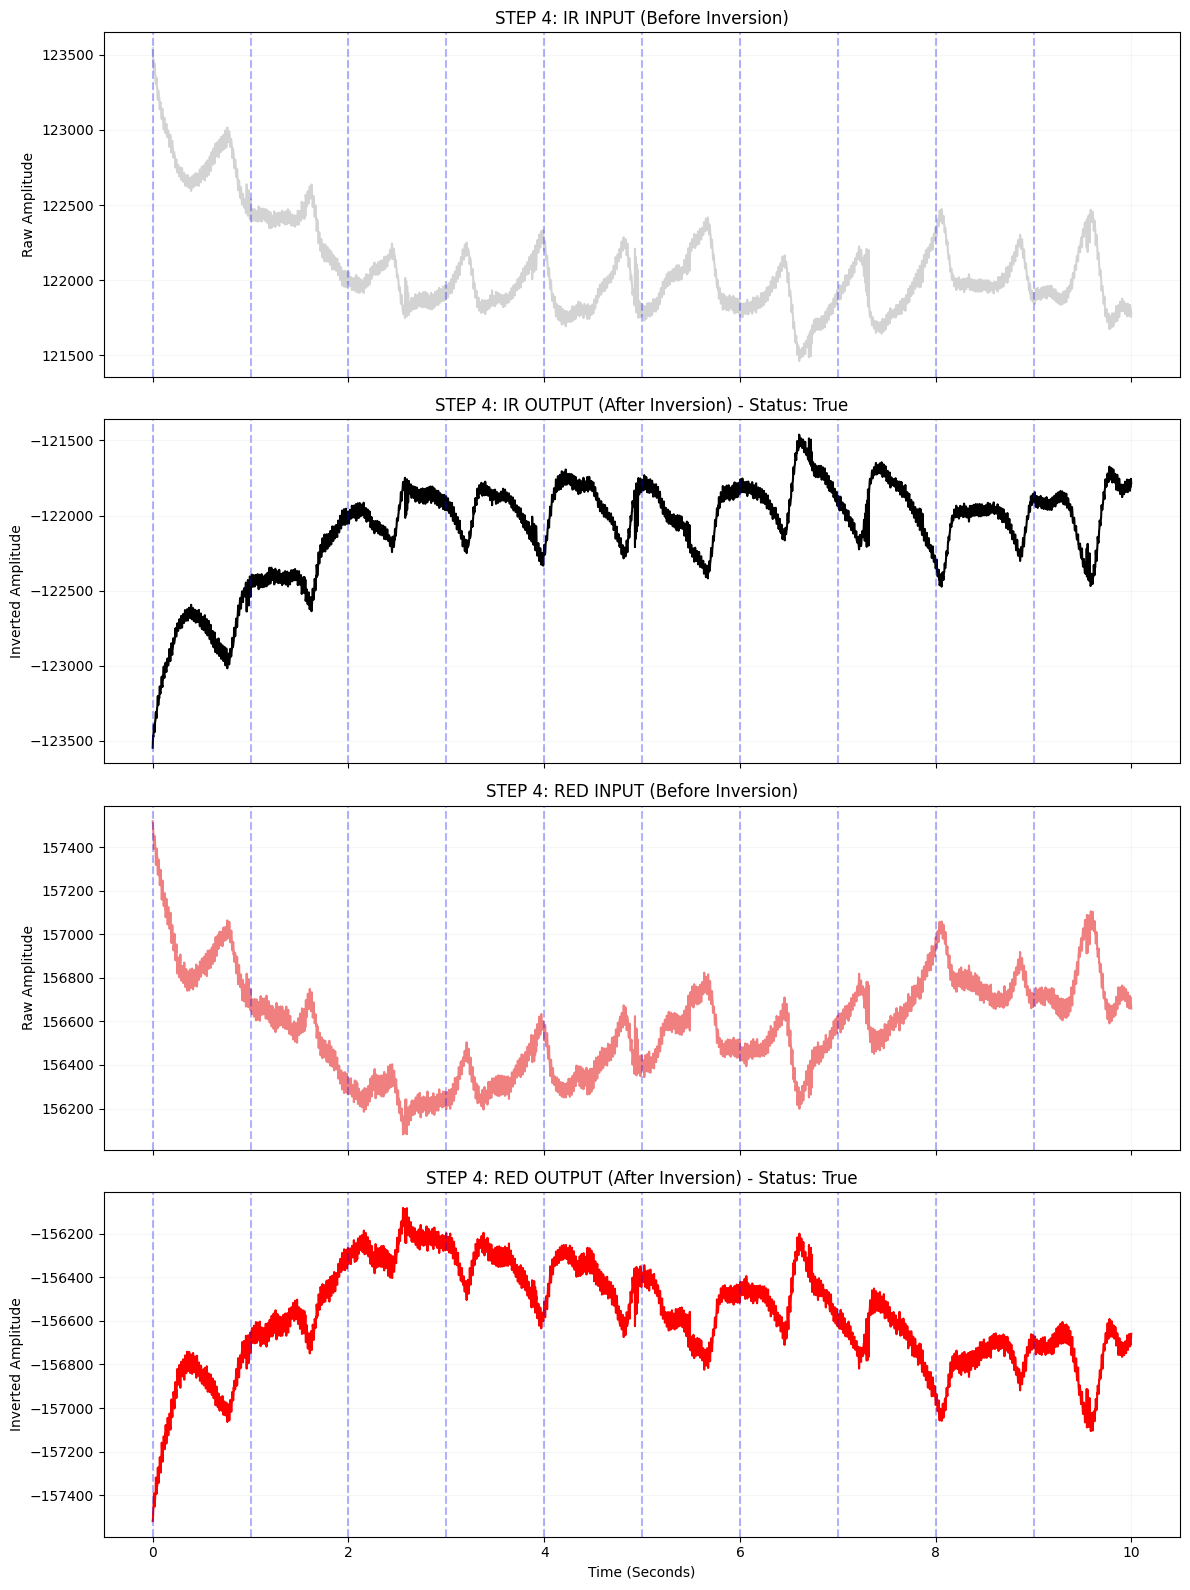

In [142]:
# ==========================================
# ⚙️ STEP 4: SIGNAL INVERSION
# ==========================================
# Fixes Morphology: MAX30102 raw values drop during a pulse.
# We multiply by -1 so the systolic peak points UP.

# 1. Apply Logic
if INVERT_ENABLE:
    print("🔄 INVERSION APPLIED: Flipping signal so Systolic Peak points UP.")
    ir_inverted  = ir_despiked * -1
    red_inverted = red_despiked * -1
else:
    print("➡️ INVERSION SKIPPED: Passing signal through.")
    ir_inverted  = ir_despiked
    red_inverted = red_despiked

# 2. Setup Plotting (4 Separate Rows)
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4 

fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height), sharex=True)
plt.subplots_adjust(hspace=0.6) # Increase spacing between plots

# --- PLOT 1: IR INPUT (Before) ---
axes[0].plot(time_axis, ir_despiked, color='lightgray', linewidth=1.5)
axes[0].set_title(f'STEP 4: IR INPUT (Before Inversion)')
axes[0].set_ylabel('Raw Amplitude')

# --- PLOT 2: IR OUTPUT (After) ---
axes[1].plot(time_axis, ir_inverted, color='black', linewidth=1.5)
axes[1].set_title(f'STEP 4: IR OUTPUT (After Inversion) - Status: {INVERT_ENABLE}')
axes[1].set_ylabel('Inverted Amplitude')

# --- PLOT 3: RED INPUT (Before) ---
axes[2].plot(time_axis, red_despiked, color='lightcoral', linewidth=1.5)
axes[2].set_title(f'STEP 4: RED INPUT (Before Inversion)')
axes[2].set_ylabel('Raw Amplitude')

# --- PLOT 4: RED OUTPUT (After) ---
axes[3].plot(time_axis, red_inverted, color='red', linewidth=1.5)
axes[3].set_title(f'STEP 4: RED OUTPUT (After Inversion) - Status: {INVERT_ENABLE}')
axes[3].set_ylabel('Inverted Amplitude')
axes[3].set_xlabel('Time (Seconds)')

# --- VERTICAL LINES (Time) ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in axes:
        for sec in grid_seconds:
            ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

⚡ LOW-PASS FILTER: ENABLED (Cutoff: 16.0Hz, Order: 4)


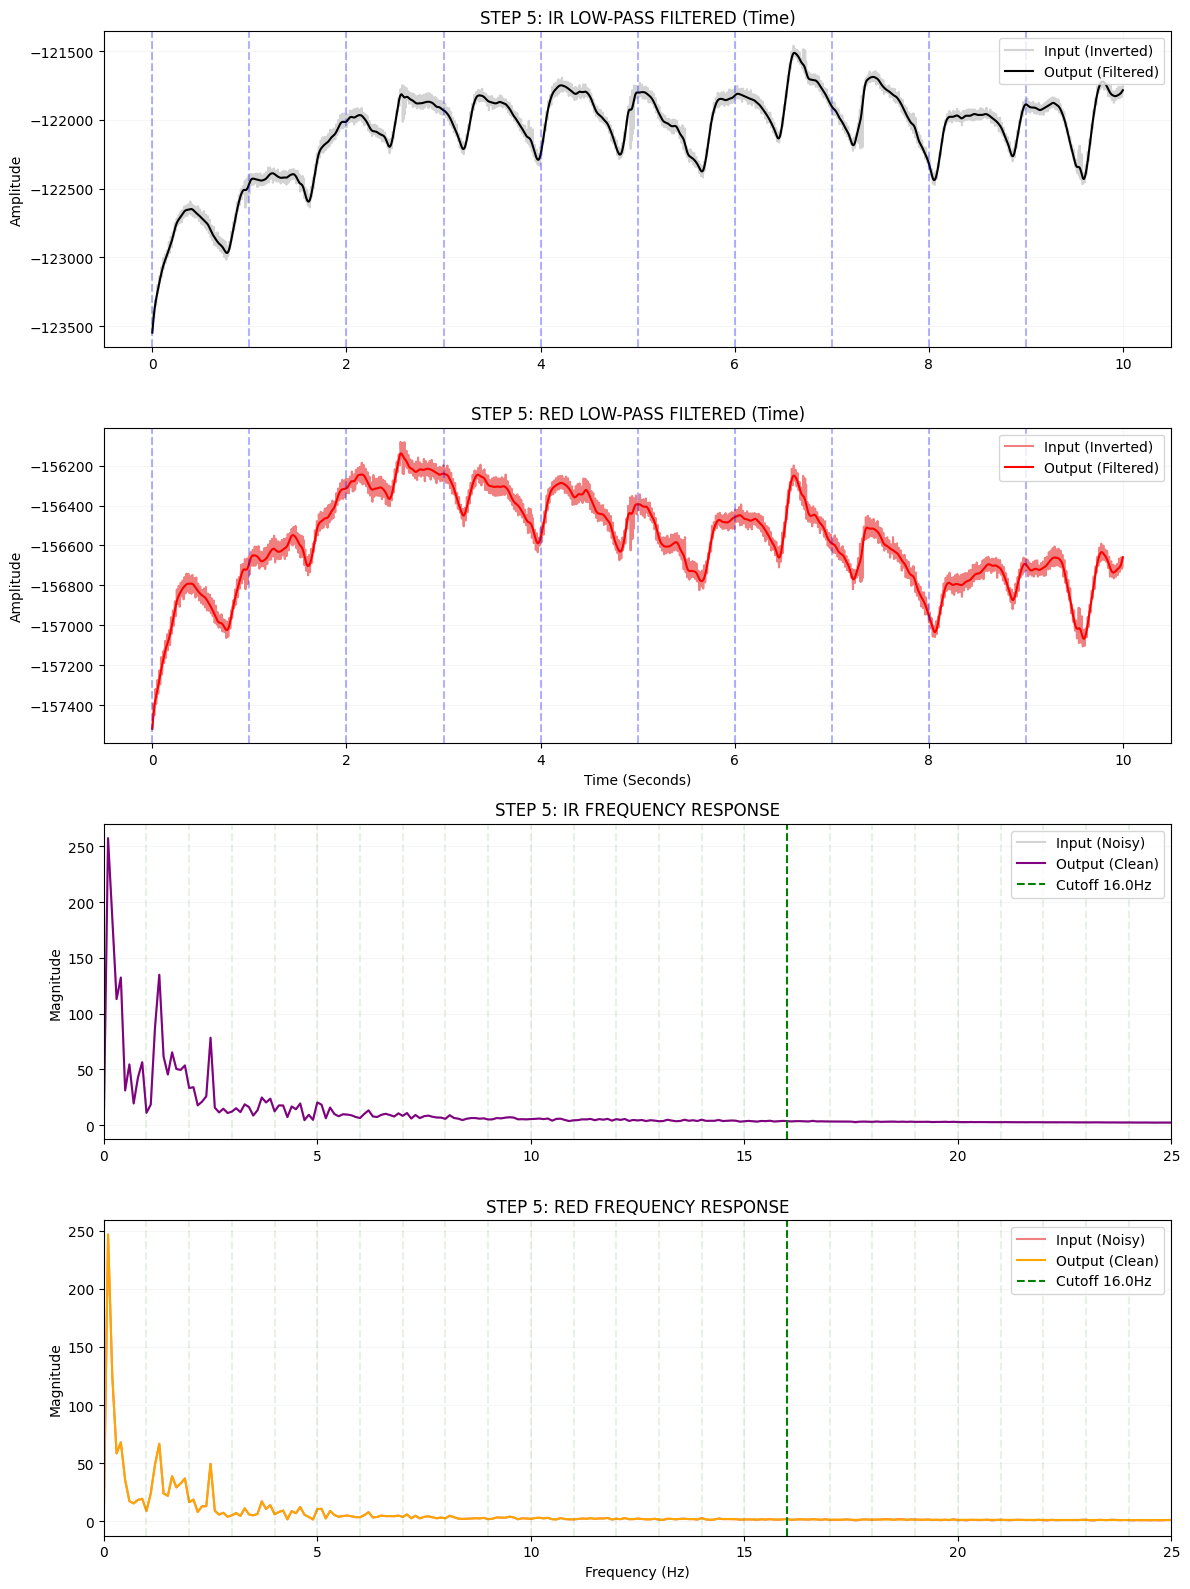

In [143]:
# ==========================================
# ⚙️ STEP 5: LOW-PASS FILTER (Noise Removal)
# ==========================================
# Removes high-frequency noise (muscle movement, electrical jitter).
# Crucial for revealing the "Dicrotic Notch".

# 1. Apply Filter Logic
if LP_ENABLE:
    print(f"⚡ LOW-PASS FILTER: ENABLED (Cutoff: {LP_CUTOFF}Hz, Order: {LP_ORDER})")
    
    nyquist = 0.5 * FS
    # Design Butterworth Filter (SOS mode for stability)
    sos = signal.butter(LP_ORDER, LP_CUTOFF / nyquist, btype='low', output='sos')
    
    # Apply Zero-Phase Filter (filtfilt)
    ir_filtered  = signal.sosfiltfilt(sos, ir_inverted)
    red_filtered = signal.sosfiltfilt(sos, red_inverted)
else:
    print("⚠️ LOW-PASS FILTER: DISABLED (Skipping...)")
    ir_filtered  = ir_inverted
    red_filtered = red_inverted

# 2. FFT Helper (Local definition for safety)
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data)) # Remove DC
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# 3. Setup Plotting (Time + Frequency)
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR TIME DOMAIN ---
axes[0].plot(time_axis, ir_inverted, color='lightgray', label='Input (Inverted)', linewidth=1.5)
axes[0].plot(time_axis, ir_filtered, color='black', label='Output (Filtered)', linewidth=1.5)
axes[0].set_title(f'STEP 5: IR LOW-PASS FILTERED (Time)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED TIME DOMAIN ---
axes[1].plot(time_axis, red_inverted, color='lightcoral', label='Input (Inverted)', linewidth=1.5)
axes[1].plot(time_axis, red_filtered, color='red', label='Output (Filtered)', linewidth=1.5)
axes[1].set_title(f'STEP 5: RED LOW-PASS FILTERED (Time)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- TIME VERTICAL LINES ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        for sec in grid_seconds:
            ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

# --- PLOT 3: IR FREQUENCY SPECTRUM ---
xf_in, yf_in   = compute_fft(ir_inverted, FS)
xf_out, yf_out = compute_fft(ir_filtered, FS)

axes[2].plot(xf_in, yf_in, color='lightgray', label='Input (Noisy)', linewidth=1.5)
axes[2].plot(xf_out, yf_out, color='purple', label='Output (Clean)', linewidth=1.5)
axes[2].axvline(LP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {LP_CUTOFF}Hz') # Mark Cutoff
axes[2].set_title('STEP 5: IR FREQUENCY RESPONSE')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 25) # Zoom to see the cutoff effect
axes[2].legend(loc='upper right')

# --- PLOT 4: RED FREQUENCY SPECTRUM ---
xf_in_r, yf_in_r   = compute_fft(red_inverted, FS)
xf_out_r, yf_out_r = compute_fft(red_filtered, FS)

axes[3].plot(xf_in_r, yf_in_r, color='lightcoral', label='Input (Noisy)', linewidth=1.5)
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Output (Clean)', linewidth=1.5)
axes[3].axvline(LP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {LP_CUTOFF}Hz')
axes[3].set_title('STEP 5: RED FREQUENCY RESPONSE')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 25)
axes[3].legend(loc='upper right')

# --- FREQ VERTICAL LINES ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    grid_freqs = np.arange(0, 25, FREQ_VERTICAL_LINE_INTERVAL)
    for ax in [axes[2], axes[3]]:
        for freq in grid_freqs:
            ax.axvline(x=freq, color='green', linestyle='--', alpha=0.1) # Faint grid
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

✨ SG SMOOTHING: ENABLED (Window: 31, Poly: 3)


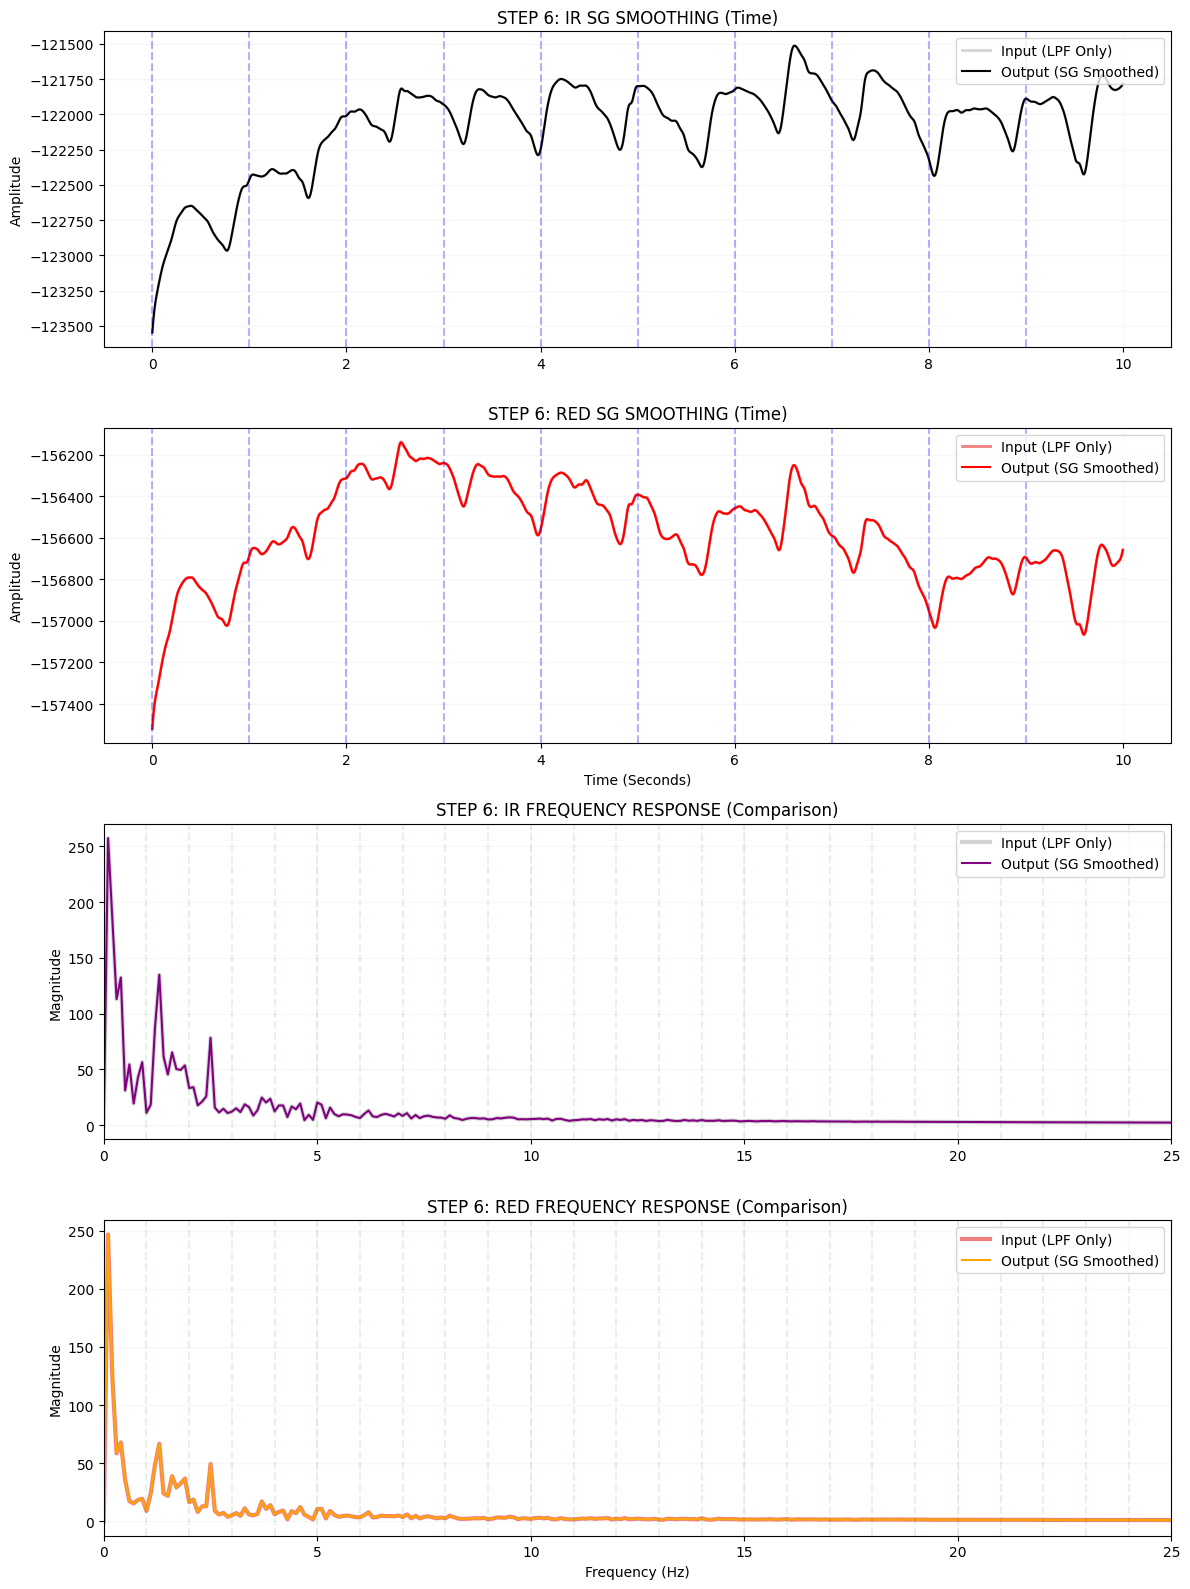

✅ Step 6 Done. Output variables: ir_smoothed, red_smoothed


In [144]:
# ==========================================
# ⚙️ STEP 6: SAVITZKY-GOLAY SMOOTHING
# ==========================================
# "Polishes" the signal while preserving peak sharpness better than standard LPF.
# Input: ir_filtered, red_filtered (from Step 5)
# Output: ir_smoothed, red_smoothed

# --- 1. Safety Check (Prevents Crashes) ---
safe_window = int(SG_WINDOW)
safe_poly   = int(SG_POLY)

# Rule: Window must be ODD
if safe_window % 2 == 0:
    safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be ODD)")

# Rule: Window must be > Poly Order
if safe_window <= safe_poly:
    safe_window = safe_poly + 2
    if safe_window % 2 == 0: safe_window += 1
    print(f"⚠️ Adjusted SG_WINDOW to {safe_window} (Must be > Poly Order)")

# --- 2. Apply Filter ---
if SG_ENABLE:
    print(f"✨ SG SMOOTHING: ENABLED (Window: {safe_window}, Poly: {safe_poly})")
    ir_smoothed  = signal.savgol_filter(ir_filtered, window_length=safe_window, polyorder=safe_poly)
    red_smoothed = signal.savgol_filter(red_filtered, window_length=safe_window, polyorder=safe_poly)
else:
    print("ℹ️ SG SMOOTHING: DISABLED (Skipping...)")
    ir_smoothed  = ir_filtered.copy()
    red_smoothed = red_filtered.copy()

# --- 3. FFT Helper ---
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# --- 4. Setup Plotting ---
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR TIME DOMAIN ---
axes[0].plot(time_axis, ir_filtered, color='lightgray', label='Input (LPF Only)', linewidth=2)
axes[0].plot(time_axis, ir_smoothed, color='black', label='Output (SG Smoothed)', linewidth=1.5)
axes[0].set_title(f'STEP 6: IR SG SMOOTHING (Time)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED TIME DOMAIN ---
axes[1].plot(time_axis, red_filtered, color='lightcoral', label='Input (LPF Only)', linewidth=2)
axes[1].plot(time_axis, red_smoothed, color='red', label='Output (SG Smoothed)', linewidth=1.5)
axes[1].set_title(f'STEP 6: RED SG SMOOTHING (Time)')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- TIME VERTICAL LINES ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        for sec in grid_seconds:
            ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

# --- PLOT 3: IR FREQUENCY SPECTRUM (Comparison) ---
xf_in, yf_in   = compute_fft(ir_filtered, FS)
xf_out, yf_out = compute_fft(ir_smoothed, FS)

axes[2].plot(xf_in, yf_in, color='lightgray', label='Input (LPF Only)', linewidth=3) # Thicker background
axes[2].plot(xf_out, yf_out, color='purple', label='Output (SG Smoothed)', linewidth=1.5)
axes[2].set_title('STEP 6: IR FREQUENCY RESPONSE (Comparison)')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 25)
axes[2].legend(loc='upper right')

# --- PLOT 4: RED FREQUENCY SPECTRUM (Comparison) ---
xf_in_r, yf_in_r   = compute_fft(red_filtered, FS)
xf_out_r, yf_out_r = compute_fft(red_smoothed, FS) 

axes[3].plot(xf_in_r, yf_in_r, color='lightcoral', label='Input (LPF Only)', linewidth=3) # Thicker background
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Output (SG Smoothed)', linewidth=1.5)
axes[3].set_title('STEP 6: RED FREQUENCY RESPONSE (Comparison)')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 25)
axes[3].legend(loc='upper right')

# --- FREQ VERTICAL LINES ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    grid_freqs = np.arange(0, 25, FREQ_VERTICAL_LINE_INTERVAL)
    for ax in [axes[2], axes[3]]:
        for freq in grid_freqs:
            ax.axvline(x=freq, color='green', linestyle='--', alpha=0.1)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

print("✅ Step 6 Done. Output variables: ir_smoothed, red_smoothed")

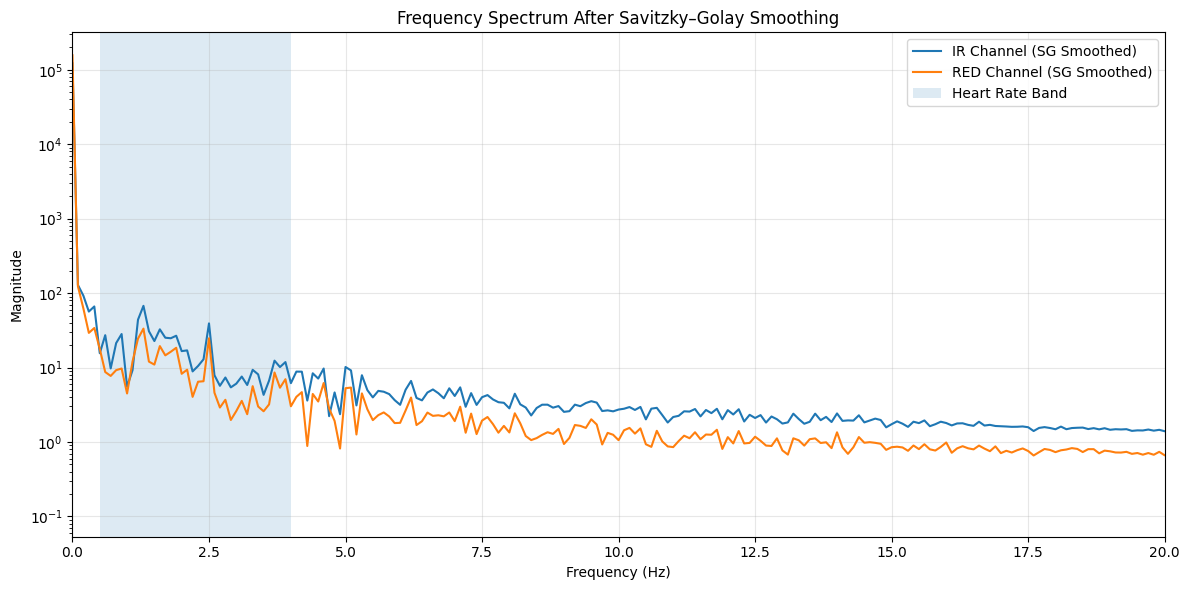

In [145]:
# ==========================================
# 📈 FREQUENCY DOMAIN ANALYSIS (FFT)
# ==========================================

def compute_fft(signal_data, fs):
    N = len(signal_data)
    fft_vals = np.fft.fft(signal_data)
    fft_vals = np.abs(fft_vals) / N
    freqs = np.fft.fftfreq(N, d=1/fs)
    return freqs[:N//2], fft_vals[:N//2]

# Compute FFTs
freq_ir, fft_ir = compute_fft(ir_filtered, FS)
freq_red, fft_red = compute_fft(red_filtered, FS)

# ==========================================
# 📊 FFT PLOTS
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(freq_ir, fft_ir, label='IR Channel (SG Smoothed)', linewidth=1.5)
plt.plot(freq_red, fft_red, label='RED Channel (SG Smoothed)', linewidth=1.5)

# Physiological heart rate band (0.5–4 Hz)
plt.axvspan(0.5, 4.0, alpha=0.15, label='Heart Rate Band')

plt.title("Frequency Spectrum After Savitzky–Golay Smoothing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 20)          # PPG useful range
plt.yscale("log")        # Better visualization
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


⚡ HIGH-PASS FILTER: ENABLED (Cutoff: 0.5Hz, Order: 4)
   -> DC Offset and Breathing Drift Removed.


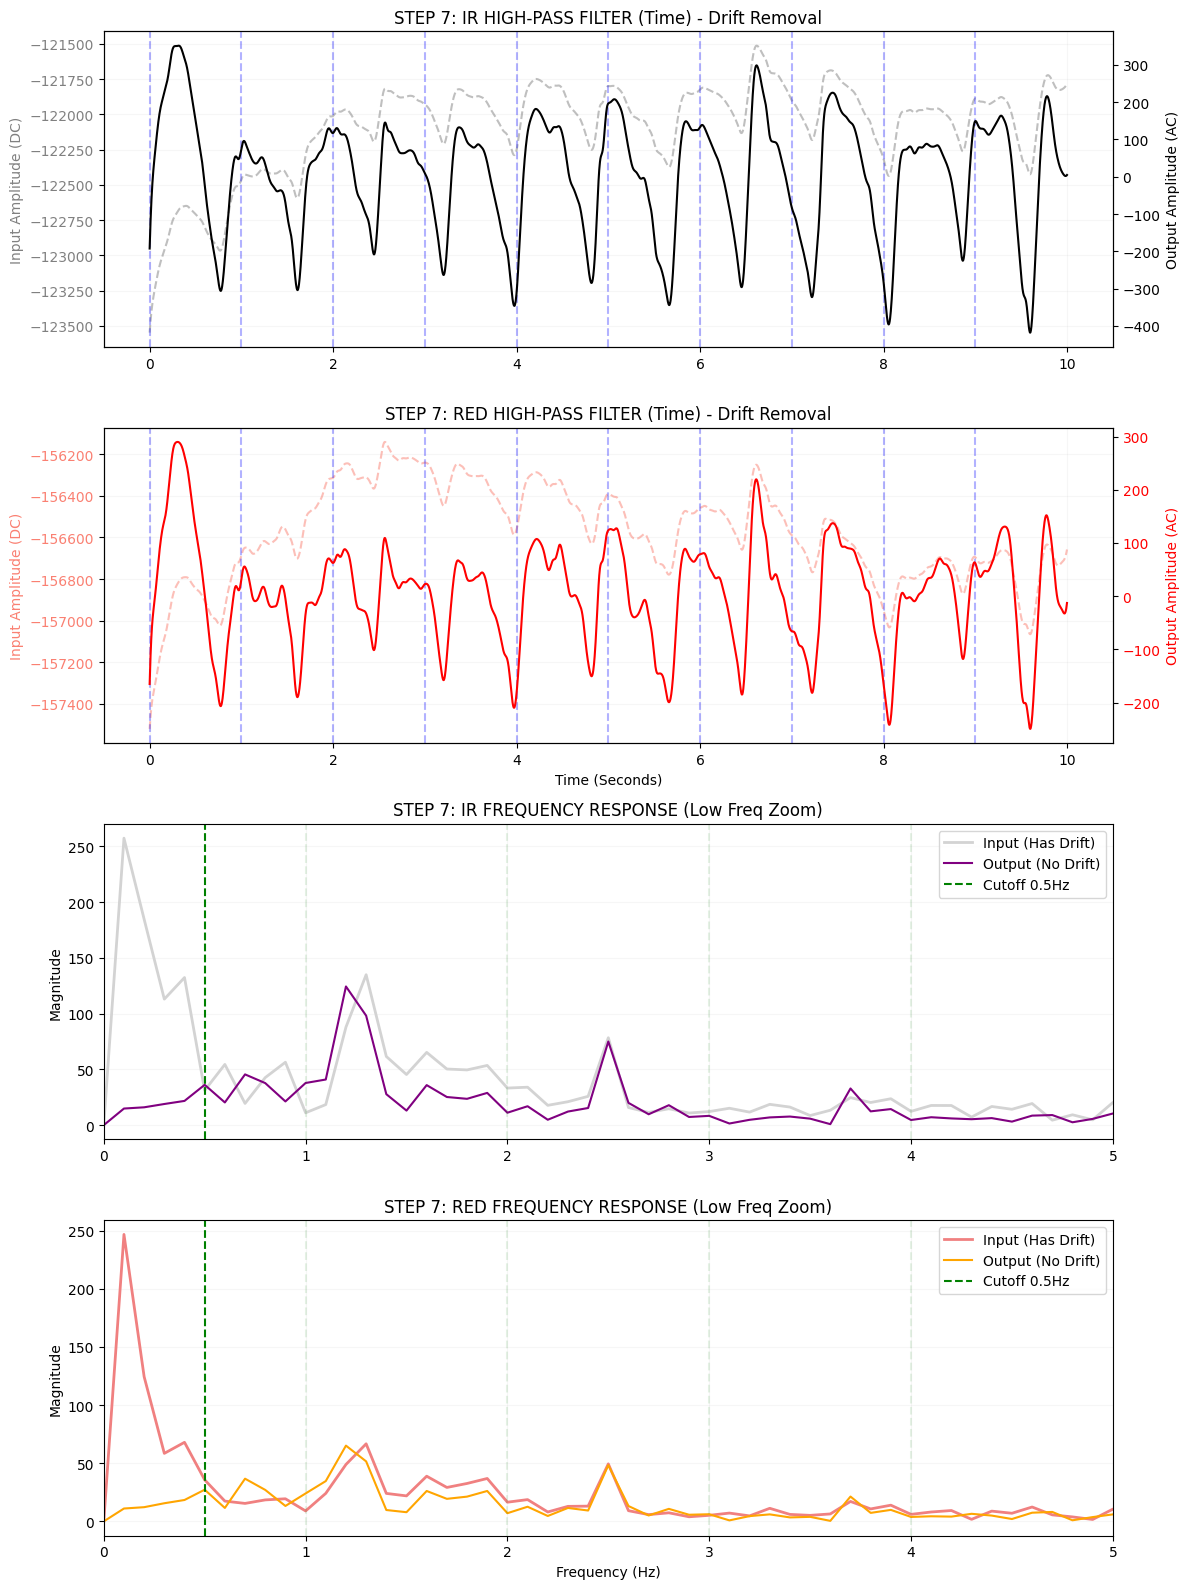

✅ Step 7 Done. Output variables: ir_hpf, red_hpf


In [146]:
# ==========================================
# ⚙️ STEP 7: HIGH-PASS FILTER
# ==========================================
# Removes low-frequency drift (breathing, posture changes).
# Input: ir_smoothed, red_smoothed (From Step 6)
# Output: ir_hpf, red_hpf

# --- 1. Apply Filter ---
if HP_ENABLE:
    print(f"⚡ HIGH-PASS FILTER: ENABLED (Cutoff: {HP_CUTOFF}Hz, Order: {HP_ORDER})")
    
    nyquist = 0.5 * FS
    # Design Butterworth High Pass
    sos_hp = signal.butter(HP_ORDER, HP_CUTOFF / nyquist, btype='high', output='sos')
    
    # Apply to the SMOOTHED signal from Step 6
    ir_hpf  = signal.sosfiltfilt(sos_hp, ir_smoothed)
    red_hpf = signal.sosfiltfilt(sos_hp, red_smoothed)
    print("   -> DC Offset and Breathing Drift Removed.")
else:
    print("ℹ️ HIGH-PASS FILTER: DISABLED (Keeping DC Offset).")
    ir_hpf  = ir_smoothed.copy()
    red_hpf = red_smoothed.copy()

# --- 2. FFT Helper ---
def compute_fft(signal_data, fs):
    N = len(signal_data)
    yf = fft(signal_data - np.mean(signal_data))
    xf = fftfreq(N, 1 / fs)
    return xf[:N//2], 2.0/N * np.abs(yf[0:N//2])

# --- 3. Setup Plotting ---
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 4
fig, axes = plt.subplots(4, 1, figsize=(12, total_fig_height))
plt.subplots_adjust(hspace=0.6)

# --- PLOT 1: IR TIME DOMAIN (Dual Axis) ---
color_in = 'gray'
color_out = 'black'

# Left Axis: Input with Drift
axes[0].plot(time_axis, ir_smoothed, color=color_in, alpha=0.5, label='Input (Step 6)', linestyle='--')
axes[0].set_ylabel('Input Amplitude (DC)', color=color_in)
axes[0].tick_params(axis='y', labelcolor=color_in)
axes[0].set_title(f'STEP 7: IR HIGH-PASS FILTER (Time) - Drift Removal')

# Right Axis: Output (Centered)
ax0_right = axes[0].twinx()
ax0_right.plot(time_axis, ir_hpf, color=color_out, linewidth=1.5, label='Output (HPF)')
ax0_right.set_ylabel('Output Amplitude (AC)', color=color_out)
ax0_right.tick_params(axis='y', labelcolor=color_out)

# --- PLOT 2: RED TIME DOMAIN (Dual Axis) ---
color_in = 'salmon'
color_out = 'red'

# Left Axis: Input with Drift
axes[1].plot(time_axis, red_smoothed, color=color_in, alpha=0.5, label='Input (Step 6)', linestyle='--')
axes[1].set_ylabel('Input Amplitude (DC)', color=color_in)
axes[1].tick_params(axis='y', labelcolor=color_in)
axes[1].set_title(f'STEP 7: RED HIGH-PASS FILTER (Time) - Drift Removal')
axes[1].set_xlabel('Time (Seconds)')

# Right Axis: Output (Centered)
ax1_right = axes[1].twinx()
ax1_right.plot(time_axis, red_hpf, color=color_out, linewidth=1.5, label='Output (HPF)')
ax1_right.set_ylabel('Output Amplitude (AC)', color=color_out)
ax1_right.tick_params(axis='y', labelcolor=color_out)

# --- TIME VERTICAL LINES ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in [axes[0], axes[1]]:
        for sec in grid_seconds:
            ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

# --- PLOT 3: IR FREQUENCY SPECTRUM ---
xf_in, yf_in   = compute_fft(ir_smoothed, FS)
xf_out, yf_out = compute_fft(ir_hpf, FS)

axes[2].plot(xf_in, yf_in, color='lightgray', label='Input (Has Drift)', linewidth=2)
axes[2].plot(xf_out, yf_out, color='purple', label='Output (No Drift)', linewidth=1.5)
axes[2].axvline(HP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {HP_CUTOFF}Hz')
axes[2].set_title('STEP 7: IR FREQUENCY RESPONSE (Low Freq Zoom)')
axes[2].set_ylabel('Magnitude')
axes[2].set_xlim(0, 5) # Zoom in to 0-5Hz to see the drift removal
axes[2].legend(loc='upper right')

# --- PLOT 4: RED FREQUENCY SPECTRUM ---
xf_in_r, yf_in_r   = compute_fft(red_smoothed, FS)
xf_out_r, yf_out_r = compute_fft(red_hpf, FS)

axes[3].plot(xf_in_r, yf_in_r, color='lightcoral', label='Input (Has Drift)', linewidth=2)
axes[3].plot(xf_out_r, yf_out_r, color='orange', label='Output (No Drift)', linewidth=1.5)
axes[3].axvline(HP_CUTOFF, color='green', linestyle='--', label=f'Cutoff {HP_CUTOFF}Hz')
axes[3].set_title('STEP 7: RED FREQUENCY RESPONSE (Low Freq Zoom)')
axes[3].set_ylabel('Magnitude')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_xlim(0, 5) # Zoom in to 0-5Hz
axes[3].legend(loc='upper right')

# --- FREQ VERTICAL LINES ---
if FREQ_VERTICAL_LINE_INTERVAL > 0:
    grid_freqs = np.arange(0, 5, FREQ_VERTICAL_LINE_INTERVAL) # Grid only up to 5Hz for this zoom
    for ax in [axes[2], axes[3]]:
        for freq in grid_freqs:
            ax.axvline(x=freq, color='green', linestyle='--', alpha=0.1)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

print("✅ Step 7 Done. Output variables: ir_hpf, red_hpf")

⚡ NORMALIZATION APPLIED: Min-Max (0-1)


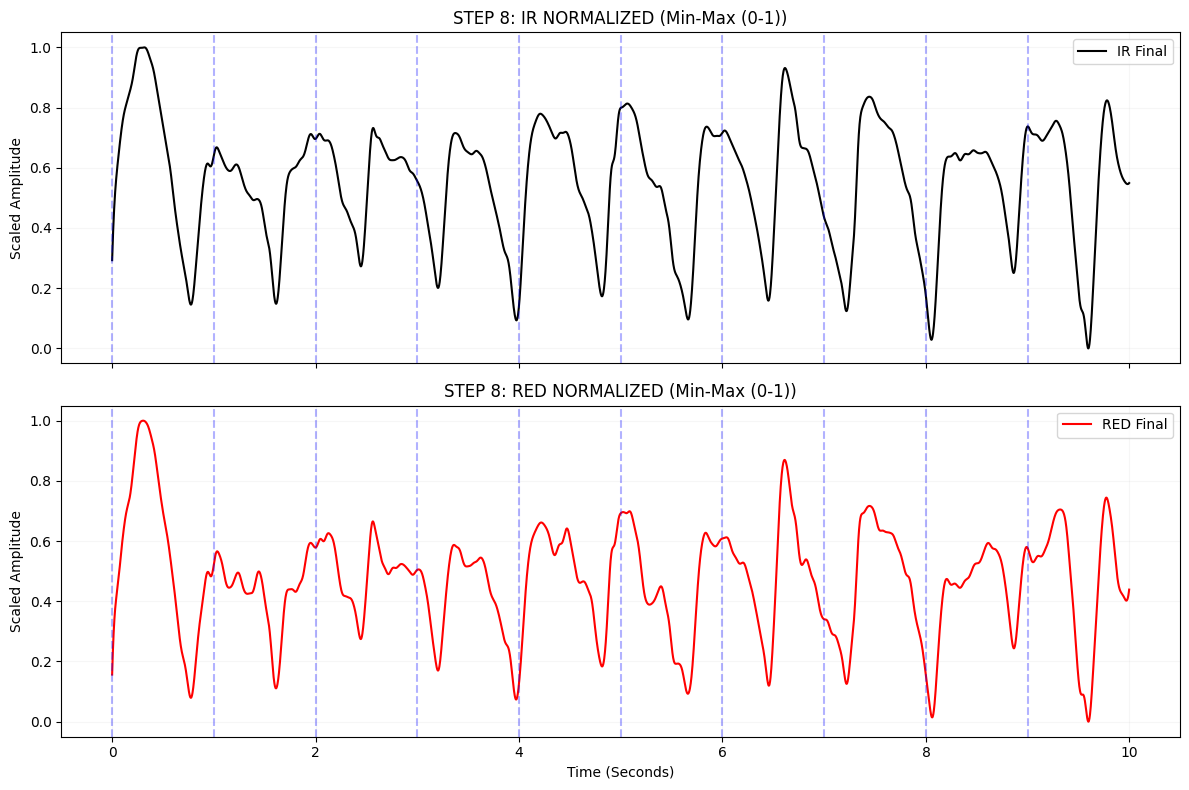


📊 FINAL STATISTICS (Check for ML Validity):
   IR  -> Min: 0.0000, Max: 1.0000, Mean: 0.5529, Std: 0.2044
   RED -> Min: 0.0000, Max: 1.0000, Mean: 0.4725, Std: 0.1826


In [147]:
# ==========================================
# ⚙️ STEP 8: NORMALIZATION
# ==========================================
# Input: ir_hpf, red_hpf (Output from Step 7)
# Output: ir_norm, red_norm (Final ML-Ready Signal)

# --- 1. Apply Normalization ---
# Uses the helper function defined in Cell 1
ir_norm  = apply_normalization(ir_hpf, selection=NORM_SELECTION)
red_norm = apply_normalization(red_hpf, selection=NORM_SELECTION)

norm_type = "Min-Max (0-1)" if NORM_SELECTION == 1 else "Z-Score (Std=1)"
print(f"⚡ NORMALIZATION APPLIED: {norm_type}")

# --- 2. Setup Plotting ---
time_axis = np.arange(len(selected_df)) / FS
total_fig_height = SUBPLOT_HEIGHT * 2
fig, axes = plt.subplots(2, 1, figsize=(12, total_fig_height), sharex=True)
plt.subplots_adjust(hspace=0.4)

# --- PLOT 1: IR FINAL ---
axes[0].plot(time_axis, ir_norm, color='black', linewidth=1.5, label='IR Final')
axes[0].set_title(f'STEP 8: IR NORMALIZED ({norm_type})')
axes[0].set_ylabel('Scaled Amplitude')
axes[0].legend(loc='upper right')

# --- PLOT 2: RED FINAL ---
axes[1].plot(time_axis, red_norm, color='red', linewidth=1.5, label='RED Final')
axes[1].set_title(f'STEP 8: RED NORMALIZED ({norm_type})')
axes[1].set_ylabel('Scaled Amplitude')
axes[1].set_xlabel('Time (Seconds)')
axes[1].legend(loc='upper right')

# --- VERTICAL LINES (Time) ---
if TIME_VERTICAL_LINE_INTERVAL > 0:
    grid_seconds = np.arange(0, time_axis[-1], TIME_VERTICAL_LINE_INTERVAL)
    for ax in axes:
        for sec in grid_seconds:
            ax.axvline(x=sec, color='blue', linestyle='--', alpha=0.3)
        ax.grid(True, which='both', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

# --- 3. Print Verification Stats ---
print("\n📊 FINAL STATISTICS (Check for ML Validity):")
print(f"   IR  -> Min: {np.min(ir_norm):.4f}, Max: {np.max(ir_norm):.4f}, Mean: {np.mean(ir_norm):.4f}, Std: {np.std(ir_norm):.4f}")
print(f"   RED -> Min: {np.min(red_norm):.4f}, Max: {np.max(red_norm):.4f}, Mean: {np.mean(red_norm):.4f}, Std: {np.std(red_norm):.4f}")

In [148]:
# ==========================================
# ⚙️ STEP 9: ADVANCED SIGNAL QUALITY CHECK
# ==========================================
# Evaluates if the signal is "Clean" enough for Machine Learning.
# Uses 'ir_hpf' and 'red_hpf' (Step 7 Output) to preserve true AC amplitude.

def calculate_snr(signal_data, fs):
    """
    Calculates Spectral Signal-to-Noise Ratio (SNR).
    Signal Power: 0.5 Hz to 5.0 Hz (Heartbeat range)
    Noise Power: Everything else up to Nyquist.
    """
    freqs, psd = signal.periodogram(signal_data, fs)
    sig_mask = (freqs >= 0.5) & (freqs <= 5.0)
    noise_mask = ~sig_mask 
    sig_power = np.sum(psd[sig_mask])
    noise_power = np.sum(psd[noise_mask])
    if noise_power == 0: return 100.0
    return 10 * np.log10(sig_power / noise_power)

def calculate_zcr(signal_data):
    """ Measures 'jitter' (Zero Crossing Rate). """
    # Data is already centered by HPF, but safety center again
    centered = signal_data - np.mean(signal_data)
    crossings = np.diff(np.signbit(centered)).sum()
    return crossings / len(signal_data)

def check_quality_advanced(name, clean_sig, raw_sig_for_dc, fs):
    print(f"\n📋 HIGH-STANDARD QUALITY REPORT: {name}")
    print("=" * 95)
    
    # --- 1. SKEWNESS (Symmetry) ---
    # Healthy pulses are positive skewed (fast up, slow down)
    skew = stats.skew(clean_sig)
    skew_min = SQI_LIMITS['SKEWNESS_MIN']
    skew_status = "✅ PASS" if skew > skew_min else "❌ FAIL (Distorted)"
    
    # --- 2. KURTOSIS (Sharpness) ---
    # Healthy pulses are sharp (Leptokurtic)
    kurt = stats.kurtosis(clean_sig)
    kurt_min = SQI_LIMITS['KURTOSIS_MIN']
    kurt_status = "✅ PASS" if kurt > kurt_min else "⚠️ WARNING (Flat)"
    
    # --- 3. PERFUSION INDEX (PI) ---
    # Ratio of AC Pulse strength to DC Baseline
    ac_amp = np.max(clean_sig) - np.min(clean_sig)
    dc_amp = np.mean(raw_sig_for_dc)
    pi = (ac_amp / dc_amp) * 100 if dc_amp != 0 else 0
    pi_min = SQI_LIMITS['PI_MIN']
    pi_status = "✅ PASS" if pi > pi_min else "❌ FAIL (Weak Signal)"

    # --- 4. SNR (Clarity) ---
    snr = calculate_snr(clean_sig, fs)
    snr_min = SQI_LIMITS['SNR_MIN_DB']
    snr_status = "✅ PASS" if snr > snr_min else "❌ FAIL (Too Noisy)"

    # --- 5. ZERO-CROSSING RATE (Stability) ---
    # High ZCR = White Noise
    zcr = calculate_zcr(clean_sig)
    zcr_max = SQI_LIMITS['ZCR_MAX']
    zcr_status = "✅ PASS" if zcr < zcr_max else "⚠️ WARNING (Jittery)"

    # --- PRINT TABLE ---
    print(f"{'METRIC':<20} | {'VALUE':<12} | {'TARGET':<15} | {'STATUS':<25}")
    print("-" * 95)
    print(f"{'Skewness':<20} | {skew:<12.4f} | > {skew_min:<13} | {skew_status}")
    print(f"{'Kurtosis':<20} | {kurt:<12.4f} | > {kurt_min:<13} | {kurt_status}")
    print(f"{'Perfusion Index':<20} | {pi:<12.4f}% | > {pi_min:<13}% | {pi_status}")
    print(f"{'SNR (dB)':<20} | {snr:<12.4f} | > {snr_min:<13} | {snr_status}")
    print(f"{'Zero-Crossing':<20} | {zcr:<12.4f} | < {zcr_max:<13} | {zcr_status}")
    print("=" * 95)

    # Global Verdict (Strict: Fail if Skew, PI, or SNR fail)
    if "❌" in (skew_status + pi_status + snr_status):
        print(f"🚨 FINAL VERDICT: REJECTED (Bad Signal Quality)")
        return False
    else:
        print(f"🎉 FINAL VERDICT: ACCEPTED (High Quality for AI)")
        return True

# --- EXECUTE CHECK ---
# We use ir_hpf/red_hpf (Step 7) because they have the true AC amplitude.
# We use selected_df (Step 2) for the DC baseline.

check_quality_advanced("RED CHANNEL", red_hpf, selected_df['RED'].values, FS)
check_quality_advanced("IR CHANNEL ", ir_hpf, selected_df['IR'].values, FS)


📋 HIGH-STANDARD QUALITY REPORT: RED CHANNEL
METRIC               | VALUE        | TARGET          | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | -0.1183      | > -1.0          | ✅ PASS
Kurtosis             | 0.2780       | > -1.0          | ✅ PASS
Perfusion Index      | 0.3445      % | > 0.1          % | ✅ PASS
SNR (dB)             | 12.2667      | > 5.0           | ✅ PASS
Zero-Crossing        | 0.0080       | < 4.0           | ✅ PASS
🎉 FINAL VERDICT: ACCEPTED (High Quality for AI)

📋 HIGH-STANDARD QUALITY REPORT: IR CHANNEL 
METRIC               | VALUE        | TARGET          | STATUS                   
-----------------------------------------------------------------------------------------------
Skewness             | -0.5123      | > -1.0          | ✅ PASS
Kurtosis             | -0.3099      | > -1.0          | ✅ PASS
Perfusion Index      | 0.6299      % | > 0.1          % | ✅ PAS

True

In [149]:
import numpy as np
import scipy.stats as stats
from scipy.signal import find_peaks

# ==========================================
# ⚙️ STEP 10: GLUCOSE FEATURE EXTRACTION
# ==========================================
# Extracts biological features for the AI Model.
# Inputs: 
#   - clean_ppg: Normalized AC signal (ir_norm / red_norm) -> For Shape
#   - raw_ppg: Original Raw Data (selected_df) -> For DC Baseline

def extract_glucose_features(clean_ppg, raw_ppg, fs):
    """
    Extracts 7 Key Features for Non-Invasive Glucose Monitoring.
    """
    # --- 1. Heart Rate (HR) & Peak Detection ---
    # distance=0.4*fs means peaks must be at least 0.4s apart (max 150 BPM)
    # prominence=0.1 avoids detecting small noise ripples
    peaks, _ = find_peaks(clean_ppg, distance=int(0.4*fs), prominence=0.1)
    
    if len(peaks) > 1:
        avg_peak_interval = np.mean(np.diff(peaks)) / fs
        hr = 60.0 / avg_peak_interval if avg_peak_interval > 0 else 0
    else:
        hr = 0
    
    # --- 2. Pulse Width (Viscosity Indicator) ---
    # Width at half-maximum amplitude
    if len(peaks) > 0:
        widths = []
        for pk in peaks:
            half_max = clean_ppg[pk] * 0.5
            left, right = pk, pk
            
            # Walk left
            while left > 0 and clean_ppg[left] > half_max:
                left -= 1
            # Walk right
            while right < len(clean_ppg)-1 and clean_ppg[right] > half_max:
                right += 1
                
            widths.append((right - left) / fs)
        avg_width = np.mean(widths) if widths else 0
    else:
        avg_width = 0
    
    # --- 3. Systolic Amplitude (Normalized) ---
    sys_amp = np.max(clean_ppg) - np.min(clean_ppg)
    
    # --- 4. Area Under Curve (Blood Volume) ---
    # Handles NumPy version differences
    if hasattr(np, 'trapezoid'):
        area = np.trapezoid(clean_ppg)
    else:
        area = np.trapz(clean_ppg)
    
    # --- 5. Skewness (Wave Symmetry) ---
    skew = stats.skew(clean_ppg)
    
    # --- 6. Kurtosis (Peak Sharpness) ---
    kurt = stats.kurtosis(clean_ppg)
    
    # --- 7. Perfusion Index (Signal Strength) ---
    # PI = (AC Amplitude / DC Baseline) * 100
    # Note: We use the RAW signal for DC mean to get true physical units
    ac_real = np.max(raw_ppg) - np.min(raw_ppg) # Estimate AC from raw
    dc_real = np.mean(raw_ppg)
    pi = (ac_real / dc_real) * 100 if dc_real > 0 else 0
    
    return {
        'hr': hr,
        'width': avg_width,
        'sys_amp': sys_amp,
        'area': area,
        'skew': skew,
        'kurt': kurt,
        'pi': pi
    }

# ==========================================
# 📊 RUN EXTRACTION & GENERATE REPORT
# ==========================================
print("\n🧬 EXTRACTING AI FEATURES...")

# Ensure inputs are correct (using variables from previous steps)
# clean_ppg = ir_norm / red_norm (Step 8)
# raw_ppg   = selected_df['IR'] / selected_df['RED'] (Step 2)

feat_red = extract_glucose_features(red_norm, selected_df['RED'].values, FS)
feat_ir  = extract_glucose_features(ir_norm, selected_df['IR'].values, FS)

# Calculate Ratio of Ratios (Standard SpO2/Glucose Metric)
if feat_ir['pi'] > 0:
    ratio_of_ratios = feat_red['pi'] / feat_ir['pi']
else:
    ratio_of_ratios = 0

# ==========================================
# 📝 ENGINEER'S REPORT
# ==========================================
print("\n" + "="*85)
print(f"📊 PPG FEATURE EXTRACTION REPORT")
print("="*85)
print(f"{'FEATURE':<25} | {'RED CHANNEL':<15} | {'IR CHANNEL':<15} | {'UNIT & MEANING'}")
print("-" * 85)

# 1. Heart Rate
print(f"{'Heart Rate (HR)':<25} | {feat_red['hr']:<15.1f} | {feat_ir['hr']:<15.1f} | BPM (Should match)")

# 2. Pulse Width (Viscosity)
print(f"{'Pulse Width':<25} | {feat_red['width']:<15.4f} | {feat_ir['width']:<15.4f} | Seconds (High Glu -> Wider)")

# 3. Systolic Amplitude
print(f"{'Systolic Amp':<25} | {feat_red['sys_amp']:<15.4f} | {feat_ir['sys_amp']:<15.4f} | Normalized Height (0-1)")

# 4. Area Under Curve
print(f"{'Area Under Curve':<25} | {feat_red['area']:<15.4f} | {feat_ir['area']:<15.4f} | Total Blood Volume")

# 5. Skewness
print(f"{'Skewness':<25} | {feat_red['skew']:<15.4f} | {feat_ir['skew']:<15.4f} | >0 means Sharp Peaks")

# 6. Kurtosis
print(f"{'Kurtosis':<25} | {feat_red['kurt']:<15.4f} | {feat_ir['kurt']:<15.4f} | Peak Sharpness")

# 7. Perfusion Index
print(f"{'Perfusion Index (PI)':<25} | {feat_red['pi']:<15.4f} | {feat_ir['pi']:<15.4f} | % (Signal Strength)")

print("-" * 85)
print(f"🧪 FINAL 'R' VALUE (RATIO):  {ratio_of_ratios:.4f}")
print("   (This 'R' value is highly correlated with Glucose Levels)")
print("="*85)


🧬 EXTRACTING AI FEATURES...

📊 PPG FEATURE EXTRACTION REPORT
FEATURE                   | RED CHANNEL     | IR CHANNEL      | UNIT & MEANING
-------------------------------------------------------------------------------------
Heart Rate (HR)           | 76.0            | 76.1            | BPM (Should match)
Pulse Width               | 0.5948          | 0.5987          | Seconds (High Glu -> Wider)
Systolic Amp              | 1.0000          | 1.0000          | Normalized Height (0-1)
Area Under Curve          | 1889.5944       | 2211.1003       | Total Blood Volume
Skewness                  | -0.1183         | -0.5123         | >0 means Sharp Peaks
Kurtosis                  | 0.2780          | -0.3099         | Peak Sharpness
Perfusion Index (PI)      | 0.9184          | 1.7078          | % (Signal Strength)
-------------------------------------------------------------------------------------
🧪 FINAL 'R' VALUE (RATIO):  0.5378
   (This 'R' value is highly correlated with Glucose Level